# ESG-Driven Portfolio Optimization - Data Pipeline
## Big Data Analytics (EECS-6893) Project
### Data Extraction, Cleaning, Preprocessing & Validation

**Team:** Sejal Mittal (sm5756) & Neha Arun Angadi (naa2204)

This notebook extracts stock price data from Yahoo Finance and ESG metrics from Kaggle's S&P 500 ESG Risk Ratings dataset, then cleans, preprocesses, and validates the data for multi-objective portfolio optimization.

---
## 1. Install Required Libraries

In [2]:
!pip install yfinance pandas numpy scikit-learn matplotlib seaborn

---
## 2. Import Libraries

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


---
## 3. Mount Google Drive & Load ESG Dataset

**Before running this cell:**
1. Upload `SP_500_ESG_Risk_Ratings.csv` to your Google Drive
2. Note the path (default assumes it's in the root of MyDrive)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Load ESG dataset from Google Drive
# CHANGE THIS PATH if your file is in a different folder
ESG_FILE_PATH = '/content/SP 500 ESG Risk Ratings.csv'

kaggle_esg = pd.read_csv(ESG_FILE_PATH)
print(f"✅ Loaded ESG data: {len(kaggle_esg)} companies")
print(f"   Columns: {list(kaggle_esg.columns)}")

Mounted at /content/drive
✅ Loaded ESG data: 503 companies
   Columns: ['Symbol', 'Name', 'Address', 'Sector', 'Industry', 'Full Time Employees', 'Description', 'Total ESG Risk score', 'Environment Risk Score', 'Governance Risk Score', 'Social Risk Score', 'Controversy Level', 'Controversy Score', 'ESG Risk Percentile', 'ESG Risk Level']


---
## 4. Define Stock Universe
Diverse set of stocks across multiple sectors to capture varying ESG profiles.

In [5]:
# Define tickers across sectors for ESG diversity
TICKERS = [
    # Technology
    'AAPL', 'MSFT', 'GOOGL', 'NVDA', 'CRM',
    # Healthcare
    'JNJ', 'PFE', 'UNH', 'MRK', 'ABBV',
    # Financials
    'JPM', 'BAC', 'GS', 'BLK', 'MS',
    # Energy (typically higher ESG risk)
    'XOM', 'CVX', 'COP', 'SLB', 'EOG',
    # Utilities
    'NEE', 'DUK', 'SO', 'D', 'AEP',
    # Consumer Staples
    'PG', 'KO', 'PEP', 'WMT', 'COST',
    # Clean Energy / EV
    'TSLA', 'ENPH', 'FSLR', 'PLUG', 'RUN',
    # Industrials
    'CAT', 'DE', 'HON', 'UPS', 'RTX'
]

SECTORS = {
    'AAPL': 'Technology', 'MSFT': 'Technology', 'GOOGL': 'Technology',
    'NVDA': 'Technology', 'CRM': 'Technology',
    'JNJ': 'Healthcare', 'PFE': 'Healthcare', 'UNH': 'Healthcare',
    'MRK': 'Healthcare', 'ABBV': 'Healthcare',
    'JPM': 'Financials', 'BAC': 'Financials', 'GS': 'Financials',
    'BLK': 'Financials', 'MS': 'Financials',
    'XOM': 'Energy', 'CVX': 'Energy', 'COP': 'Energy',
    'SLB': 'Energy', 'EOG': 'Energy',
    'NEE': 'Utilities', 'DUK': 'Utilities', 'SO': 'Utilities',
    'D': 'Utilities', 'AEP': 'Utilities',
    'PG': 'Consumer Staples', 'KO': 'Consumer Staples', 'PEP': 'Consumer Staples',
    'WMT': 'Consumer Staples', 'COST': 'Consumer Staples',
    'TSLA': 'Clean Energy', 'ENPH': 'Clean Energy', 'FSLR': 'Clean Energy',
    'PLUG': 'Clean Energy', 'RUN': 'Clean Energy',
    'CAT': 'Industrials', 'DE': 'Industrials', 'HON': 'Industrials',
    'UPS': 'Industrials', 'RTX': 'Industrials'
}

print(f"📊 Stock Universe: {len(TICKERS)} tickers across {len(set(SECTORS.values()))} sectors")
for sector in sorted(set(SECTORS.values())):
    tickers_in_sector = [t for t, s in SECTORS.items() if s == sector]
    print(f"   {sector}: {', '.join(tickers_in_sector)}")

📊 Stock Universe: 40 tickers across 8 sectors
   Clean Energy: TSLA, ENPH, FSLR, PLUG, RUN
   Consumer Staples: PG, KO, PEP, WMT, COST
   Energy: XOM, CVX, COP, SLB, EOG
   Financials: JPM, BAC, GS, BLK, MS
   Healthcare: JNJ, PFE, UNH, MRK, ABBV
   Industrials: CAT, DE, HON, UPS, RTX
   Technology: AAPL, MSFT, GOOGL, NVDA, CRM
   Utilities: NEE, DUK, SO, D, AEP


---
## 5. Extract Stock Price Data from Yahoo Finance
This demonstrates **Velocity** (daily updates) and **Volume** (thousands of records) of Big Data.

In [6]:
# Download 3 years of historical data
END_DATE = datetime.now().strftime('%Y-%m-%d')
START_DATE = (datetime.now() - timedelta(days=3*365)).strftime('%Y-%m-%d')

print(f"📥 Downloading stock data from {START_DATE} to {END_DATE}...")
print("This may take a minute...\n")

# Download all tickers at once
stock_data = yf.download(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE,
    group_by='ticker',
    auto_adjust=True,
    progress=True
)

print(f"\n✅ Downloaded data shape: {stock_data.shape}")

📥 Downloading stock data from 2022-11-16 to 2025-11-15...
This may take a minute...



[*********************100%***********************]  40 of 40 completed


✅ Downloaded data shape: (752, 200)


In [7]:
# Reshape data into long format
price_records = []

for ticker in TICKERS:
    try:
        ticker_data = stock_data[ticker].copy()
        ticker_data['Ticker'] = ticker
        ticker_data['Sector'] = SECTORS[ticker]
        ticker_data = ticker_data.reset_index()
        price_records.append(ticker_data)
    except Exception as e:
        print(f"⚠️ Error processing {ticker}: {e}")

price_df = pd.concat(price_records, ignore_index=True)
price_df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker', 'Sector']

print(f"📊 Total price records: {len(price_df):,}")
print(f"   Date range: {price_df['Date'].min().strftime('%Y-%m-%d')} to {price_df['Date'].max().strftime('%Y-%m-%d')}")
print(f"   Unique tickers: {price_df['Ticker'].nunique()}")
print(f"\nFirst few records:")
price_df.head()

📊 Total price records: 30,080
   Date range: 2022-11-16 to 2025-11-14
   Unique tickers: 40

First few records:


,Date,Open,High,Low,Close,Volume,Ticker,Sector
0,2022-11-16,146.9136,147.6426,145.1010,146.5787,64218300,AAPL,Technology
1,2022-11-17,144.2537,149.2287,143.9779,148.4800,80389400,AAPL,Technology
2,2022-11-18,150.0464,150.4306,147.7412,149.0415,74829600,AAPL,Technology
3,2022-11-21,147.9283,148.1352,145.5246,145.8103,58724100,AAPL,Technology
4,2022-11-22,145.9285,148.1845,144.7463,147.9480,51804100,AAPL,Technology


---
## 6. Map ESG Data from Kaggle Dataset
Integrate the S&P 500 ESG Risk Ratings with your stock universe.

In [8]:
print("🌱 Mapping ESG Data from Kaggle S&P 500 ESG Risk Ratings...\n")

esg_records = []

for ticker in TICKERS:
    match = kaggle_esg[kaggle_esg['Symbol'] == ticker]

    if len(match) > 0:
        row = match.iloc[0]

        # Extract risk scores (LOWER = BETTER in risk terms)
        total_risk = row['Total ESG Risk score']
        env_risk = row['Environment Risk Score']
        soc_risk = row['Social Risk Score']
        gov_risk = row['Governance Risk Score']

        # Convert RISK scores to QUALITY scores
        # Risk scores range 0-50ish, invert to 0-100 quality scale
        if pd.notna(total_risk):
            total_esg_quality = max(0, 100 - total_risk * 2)
            env_quality = max(0, 100 - env_risk * 2) if pd.notna(env_risk) else np.nan
            soc_quality = max(0, 100 - soc_risk * 2) if pd.notna(soc_risk) else np.nan
            gov_quality = max(0, 100 - gov_risk * 2) if pd.notna(gov_risk) else np.nan

            esg_records.append({
                'Ticker': ticker,
                'Sector': SECTORS[ticker],
                'Total_ESG_Score': round(total_esg_quality, 2),
                'E_Score': round(env_quality, 2) if pd.notna(env_quality) else np.nan,
                'S_Score': round(soc_quality, 2) if pd.notna(soc_quality) else np.nan,
                'G_Score': round(gov_quality, 2) if pd.notna(gov_quality) else np.nan,
                'ESG_Risk_Score': total_risk,
                'Controversy_Level': row['Controversy Level'],
                'Controversy_Score': row['Controversy Score'],
                'ESG_Risk_Percentile': row['ESG Risk Percentile'],
                'ESG_Risk_Level': row['ESG Risk Level']
            })
            print(f"✅ {ticker}: ESG Quality = {total_esg_quality:.1f} (Risk: {total_risk})")
        else:
            print(f"⚠️ {ticker}: In dataset but ESG data is empty")
            esg_records.append({
                'Ticker': ticker,
                'Sector': SECTORS[ticker],
                'Total_ESG_Score': np.nan,
                'E_Score': np.nan,
                'S_Score': np.nan,
                'G_Score': np.nan
            })
    else:
        print(f"❌ {ticker}: Not in Kaggle dataset")
        esg_records.append({
            'Ticker': ticker,
            'Sector': SECTORS[ticker],
            'Total_ESG_Score': np.nan,
            'E_Score': np.nan,
            'S_Score': np.nan,
            'G_Score': np.nan
        })

esg_df = pd.DataFrame(esg_records)
print(f"\n📊 ESG Data Coverage: {esg_df['Total_ESG_Score'].notna().sum()}/{len(TICKERS)} tickers")

🌱 Mapping ESG Data from Kaggle S&P 500 ESG Risk Ratings...

✅ AAPL: ESG Quality = 65.6 (Risk: 17.2)
✅ MSFT: ESG Quality = 69.8 (Risk: 15.1)
✅ GOOGL: ESG Quality = 51.6 (Risk: 24.2)
✅ NVDA: ESG Quality = 72.8 (Risk: 13.6)
✅ CRM: ESG Quality = 70.2 (Risk: 14.9)
✅ JNJ: ESG Quality = 52.0 (Risk: 24.0)
✅ PFE: ESG Quality = 50.8 (Risk: 24.6)
✅ UNH: ESG Quality = 69.4 (Risk: 15.3)
✅ MRK: ESG Quality = 57.2 (Risk: 21.4)
✅ ABBV: ESG Quality = 40.2 (Risk: 29.9)
✅ JPM: ESG Quality = 41.4 (Risk: 29.3)
✅ BAC: ESG Quality = 43.4 (Risk: 28.3)
✅ GS: ESG Quality = 49.0 (Risk: 25.5)
✅ BLK: ESG Quality = 63.4 (Risk: 18.3)
✅ MS: ESG Quality = 50.8 (Risk: 24.6)
✅ XOM: ESG Quality = 16.8 (Risk: 41.6)
✅ CVX: ESG Quality = 26.8 (Risk: 36.6)
✅ COP: ESG Quality = 32.2 (Risk: 33.9)
✅ SLB: ESG Quality = 59.4 (Risk: 20.3)
✅ EOG: ESG Quality = 31.6 (Risk: 34.2)
✅ NEE: ESG Quality = 53.4 (Risk: 23.3)
✅ DUK: ESG Quality = 46.0 (Risk: 27.0)
✅ SO: ESG Quality = 34.0 (Risk: 33.0)
✅ D: ESG Quality = 47.2 (Risk: 26.4)
✅ A

In [9]:
# Handle missing ESG scores by sector median imputation
print("🔧 Imputing missing ESG scores...\n")

esg_df_clean = esg_df.copy()
missing_tickers = esg_df_clean[esg_df_clean['Total_ESG_Score'].isna()]['Ticker'].tolist()

if missing_tickers:
    print(f"Missing ESG data for: {missing_tickers}")

    # Impute by sector median
    for col in ['Total_ESG_Score', 'E_Score', 'S_Score', 'G_Score']:
        esg_df_clean[col] = esg_df_clean.groupby('Sector')[col].transform(
            lambda x: x.fillna(x.median())
        )
        # Fill any remaining with overall median
        esg_df_clean[col] = esg_df_clean[col].fillna(esg_df_clean[col].median())

    print("\n✅ Missing values imputed using sector medians")
else:
    print("✅ No missing ESG scores!")

print(f"\n📊 ESG Score Statistics:")
print(f"   Mean: {esg_df_clean['Total_ESG_Score'].mean():.2f}")
print(f"   Min: {esg_df_clean['Total_ESG_Score'].min():.2f}")
print(f"   Max: {esg_df_clean['Total_ESG_Score'].max():.2f}")
print(f"   Std: {esg_df_clean['Total_ESG_Score'].std():.2f}")

print("\n✅ ESG Data Ready!")
esg_df_clean.head(10)

🔧 Imputing missing ESG scores...

Missing ESG data for: ['ENPH', 'FSLR', 'PLUG', 'RUN', 'RTX']

✅ Missing values imputed using sector medians

📊 ESG Score Statistics:
   Mean: 49.84
   Min: 16.80
   Max: 72.80
   Std: 12.44

✅ ESG Data Ready!


,Ticker,Sector,Total_ESG_Score,E_Score,S_Score,G_Score,ESG_Risk_Score,Controversy_Level,Controversy_Score,ESG_Risk_Percentile,ESG_Risk_Level
0,AAPL,Technology,65.6000,99.0000,85.2000,81.2000,17.2000,Significant Controversy Level,3.0000,18th percentile,Low
1,MSFT,Technology,69.8000,97.0000,85.0000,87.8000,15.1000,Significant Controversy Level,3.0000,11th percentile,Low
2,GOOGL,Technology,51.6000,96.8000,77.6000,77.0000,24.2000,High Controversy Level,4.0000,46th percentile,Medium
3,NVDA,Technology,72.8000,95.4000,90.2000,87.4000,13.6000,Moderate Controversy Level,2.0000,8th percentile,Low
4,CRM,Technology,70.2000,96.0000,85.0000,89.2000,14.9000,Low Controversy Level,1.0000,11th percentile,Low
5,JNJ,Healthcare,52.0000,98.2000,70.0000,84.0000,24.0000,High Controversy Level,4.0000,45th percentile,Medium
6,PFE,Healthcare,50.8000,95.8000,74.2000,80.8000,24.6000,Significant Controversy Level,3.0000,47th percentile,Medium
7,UNH,Healthcare,69.4000,100.0000,80.6000,88.8000,15.3000,Significant Controversy Level,3.0000,12th percentile,Low
8,MRK,Healthcare,57.2000,96.2000,78.8000,82.2000,21.4000,Significant Controversy Level,3.0000,34th percentile,Medium
9,ABBV,Healthcare,40.2000,95.2000,65.6000,79.2000,29.9000,Significant Controversy Level,3.0000,69th percentile,Medium


---
## 7. Clean Stock Price Data

In [10]:
print("🧹 CLEANING STOCK PRICE DATA\n")
print("=" * 50)

# Check for missing values
print("Missing values in price data:")
missing_prices = price_df.isnull().sum()
print(missing_prices[missing_prices > 0] if missing_prices.sum() > 0 else "None")

# Check for duplicates
duplicates = price_df.duplicated(subset=['Date', 'Ticker']).sum()
print(f"\nDuplicate records: {duplicates}")

# Remove duplicates
price_df_clean = price_df.drop_duplicates(subset=['Date', 'Ticker'])

# Handle missing prices using forward fill
price_df_clean = price_df_clean.sort_values(['Ticker', 'Date'])
price_df_clean = price_df_clean.groupby('Ticker').apply(
    lambda x: x.fillna(method='ffill').fillna(method='bfill')
).reset_index(drop=True)

# Check for outliers
price_df_clean['Daily_Return'] = price_df_clean.groupby('Ticker')['Close'].pct_change()
outliers = price_df_clean[abs(price_df_clean['Daily_Return']) > 0.5]
print(f"Potential outliers (>50% daily change): {len(outliers)}")

# Validate price data integrity
invalid_prices = price_df_clean[
    (price_df_clean['High'] < price_df_clean['Low']) |
    (price_df_clean['Close'] < 0) |
    (price_df_clean['Volume'] < 0)
]
print(f"Invalid price records: {len(invalid_prices)}")

print(f"\n✅ Cleaned price data: {len(price_df_clean):,} records")

🧹 CLEANING STOCK PRICE DATA

Missing values in price data:
None

Duplicate records: 0
Potential outliers (>50% daily change): 0
Invalid price records: 0

✅ Cleaned price data: 30,080 records


---
## 8. Feature Engineering
Create financial features for portfolio optimization and RL models.

In [11]:
print("⚙️ FEATURE ENGINEERING - FINANCIAL METRICS\n")
print("=" * 50)

financial_features = []

for ticker in TICKERS:
    ticker_data = price_df_clean[price_df_clean['Ticker'] == ticker].sort_values('Date').copy()

    if len(ticker_data) < 252:
        print(f"⚠️ {ticker}: Insufficient data ({len(ticker_data)} days)")
        continue

    # Calculate returns
    ticker_data['Daily_Return'] = ticker_data['Close'].pct_change()
    ticker_data['Log_Return'] = np.log(ticker_data['Close'] / ticker_data['Close'].shift(1))

    # Key metrics
    features = {
        'Ticker': ticker,
        'Sector': SECTORS[ticker],

        # Returns
        'Mean_Daily_Return': ticker_data['Daily_Return'].mean(),
        'Annualized_Return': ticker_data['Daily_Return'].mean() * 252,

        # Risk metrics
        'Daily_Volatility': ticker_data['Daily_Return'].std(),
        'Annualized_Volatility': ticker_data['Daily_Return'].std() * np.sqrt(252),

        # Risk-adjusted metrics
        'Sharpe_Ratio': (ticker_data['Daily_Return'].mean() * 252) /
                        (ticker_data['Daily_Return'].std() * np.sqrt(252)) if ticker_data['Daily_Return'].std() > 0 else 0,

        # Downside risk
        'Max_Drawdown': (ticker_data['Close'] / ticker_data['Close'].cummax() - 1).min(),
        'Downside_Deviation': ticker_data[ticker_data['Daily_Return'] < 0]['Daily_Return'].std(),

        # Higher moments
        'Skewness': ticker_data['Daily_Return'].skew(),
        'Kurtosis': ticker_data['Daily_Return'].kurtosis(),

        # Trading metrics
        'Avg_Volume': ticker_data['Volume'].mean(),
        'Volume_Volatility': ticker_data['Volume'].std() / ticker_data['Volume'].mean(),

        # Price levels
        'Current_Price': ticker_data['Close'].iloc[-1],
        'Price_52W_High': ticker_data['Close'].tail(252).max(),
        'Price_52W_Low': ticker_data['Close'].tail(252).min(),

        # Momentum
        'Return_1M': (ticker_data['Close'].iloc[-1] / ticker_data['Close'].iloc[-21] - 1) if len(ticker_data) > 21 else np.nan,
        'Return_3M': (ticker_data['Close'].iloc[-1] / ticker_data['Close'].iloc[-63] - 1) if len(ticker_data) > 63 else np.nan,
        'Return_6M': (ticker_data['Close'].iloc[-1] / ticker_data['Close'].iloc[-126] - 1) if len(ticker_data) > 126 else np.nan,
        'Return_1Y': (ticker_data['Close'].iloc[-1] / ticker_data['Close'].iloc[-252] - 1) if len(ticker_data) > 252 else np.nan,
    }

    financial_features.append(features)

financial_df = pd.DataFrame(financial_features)
print(f"✅ Calculated {len(financial_df.columns) - 2} financial features for {len(financial_df)} stocks")
print(f"\nKey Features:")
financial_df[['Ticker', 'Annualized_Return', 'Annualized_Volatility', 'Sharpe_Ratio', 'Max_Drawdown']].head(10)

⚙️ FEATURE ENGINEERING - FINANCIAL METRICS

✅ Calculated 18 financial features for 40 stocks

Key Features:


,Ticker,Annualized_Return,Annualized_Volatility,Sharpe_Ratio,Max_Drawdown
0,AAPL,0.2425,0.2635,0.9201,-0.3336
1,MSFT,0.2857,0.2361,1.2104,-0.2373
2,GOOGL,0.3935,0.3033,1.2970,-0.2981
3,NVDA,0.9623,0.5103,1.8857,-0.3688
4,CRM,0.2113,0.3335,0.6336,-0.3676
5,JNJ,0.0860,0.1700,0.5056,-0.1743
6,PFE,-0.1309,0.2421,-0.5408,-0.5531
7,UNH,-0.0790,0.3377,-0.2339,-0.6139
8,MRK,0.0332,0.2341,0.1417,-0.4344
9,ABBV,0.2065,0.2307,0.8954,-0.2074


In [12]:
# Merge financial and ESG data
print("🔗 MERGING FINANCIAL AND ESG DATA\n")
print("=" * 50)

combined_df = financial_df.merge(esg_df_clean, on=['Ticker', 'Sector'], how='left')

print(f"Combined dataset shape: {combined_df.shape}")
print(f"Total features: {len(combined_df.columns)}")

# Create ESG-adjusted metrics
combined_df['ESG_Adjusted_Sharpe'] = combined_df['Sharpe_Ratio'] * (combined_df['Total_ESG_Score'] / 50)
combined_df['ESG_Penalty'] = 1 - (combined_df['Total_ESG_Score'] / 100)
combined_df['RRE_Score'] = (
    0.4 * combined_df['Annualized_Return'] / combined_df['Annualized_Return'].abs().max() +
    0.3 * (1 - combined_df['Annualized_Volatility'] / combined_df['Annualized_Volatility'].max()) +
    0.3 * combined_df['Total_ESG_Score'] / 100
)

print("\n✅ Added ESG-adjusted metrics:")
print("   - ESG_Adjusted_Sharpe (Sharpe weighted by ESG quality)")
print("   - ESG_Penalty (penalty factor for low ESG)")
print("   - RRE_Score (Risk-Return-ESG composite)")

combined_df.head()

🔗 MERGING FINANCIAL AND ESG DATA

Combined dataset shape: (40, 29)
Total features: 29

✅ Added ESG-adjusted metrics:
   - ESG_Adjusted_Sharpe (Sharpe weighted by ESG quality)
   - ESG_Penalty (penalty factor for low ESG)
   - RRE_Score (Risk-Return-ESG composite)


,Ticker,Sector,Mean_Daily_Return,Annualized_Return,Daily_Volatility,Annualized_Volatility,Sharpe_Ratio,Max_Drawdown,Downside_Deviation,Skewness,Kurtosis,Avg_Volume,Volume_Volatility,Current_Price,Price_52W_High,Price_52W_Low,Return_1M,Return_3M,Return_6M,Return_1Y,Total_ESG_Score,E_Score,S_Score,G_Score,ESG_Risk_Score,Controversy_Level,Controversy_Score,ESG_Risk_Percentile,ESG_Risk_Level,ESG_Adjusted_Sharpe,ESG_Penalty,RRE_Score
0,AAPL,Technology,0.0010,0.2425,0.0166,0.2635,0.9201,-0.3336,0.0116,0.7559,11.8586,58215056.3830,0.4240,272.4100,275.2500,171.8324,0.0808,0.1827,0.3075,0.2155,65.6000,99.0000,85.2000,81.2000,17.2000,Significant Controversy Level,3.0000,18th percentile,Low,1.2072,0.3440,0.5192
1,MSFT,Technology,0.0011,0.2857,0.0149,0.2361,1.2104,-0.2373,0.0096,0.5385,4.9598,23607602.6596,0.4052,510.1800,542.0700,353.3294,-0.0066,0.0024,0.1136,0.2089,69.8000,97.0000,85.0000,87.8000,15.1000,Significant Controversy Level,3.0000,11th percentile,Low,1.6897,0.3020,0.5580
2,GOOGL,Technology,0.0016,0.3935,0.0191,0.3033,1.2970,-0.2981,0.0130,0.1144,4.2233,31621988.0319,0.4283,276.4100,291.3100,144.3959,0.0912,0.3725,0.6632,0.5520,51.6000,96.8000,77.6000,77.0000,24.2000,High Controversy Level,4.0000,46th percentile,Medium,1.3385,0.4840,0.5282
3,NVDA,Technology,0.0038,0.9623,0.0321,0.5103,1.8857,-0.3688,0.0200,0.7757,7.4759,367327193.6170,0.4752,190.1700,207.0400,94.2981,0.0379,0.0828,0.4029,0.3005,72.8000,95.4000,90.2000,87.4000,13.6000,Moderate Controversy Level,2.0000,8th percentile,Low,2.7455,0.2720,0.7667
4,CRM,Technology,0.0008,0.2113,0.0210,0.3335,0.6336,-0.3676,0.0160,-0.6658,13.4471,6971921.1436,0.6576,243.6600,365.6567,231.2573,0.0024,-0.0078,-0.1500,-0.2826,70.2000,96.0000,85.0000,89.2000,14.9000,Low Controversy Level,1.0000,11th percentile,Low,0.8895,0.2980,0.4993


---
## 9. Data Preprocessing for ML/RL Models

In [13]:
print("🔧 PREPROCESSING FOR OPTIMIZATION MODELS\n")
print("=" * 50)

# Select features for modeling
feature_columns = [
    'Annualized_Return', 'Annualized_Volatility', 'Sharpe_Ratio',
    'Max_Drawdown', 'Downside_Deviation', 'Skewness', 'Kurtosis',
    'Return_1M', 'Return_3M', 'Return_6M', 'Return_1Y'
]

# Add ESG features
esg_feature_cols = ['Total_ESG_Score', 'E_Score', 'S_Score', 'G_Score']
for col in esg_feature_cols:
    if col in combined_df.columns and combined_df[col].notna().any():
        feature_columns.append(col)
        print(f"✅ Added {col} to features")

# Extract feature matrix
X = combined_df[feature_columns].copy()

print(f"\nMissing values before imputation:")
missing_counts = X.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "None")

# Impute any remaining missing values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=feature_columns,
    index=combined_df.index
)

print(f"\nMissing values after imputation: {X_imputed.isnull().sum().sum()}")

# Standardize features
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=feature_columns,
    index=combined_df.index
)

print(f"\n✅ Preprocessed feature matrix shape: {X_scaled.shape}")
print(f"\nFeature statistics after scaling:")
X_scaled.describe().round(4)

🔧 PREPROCESSING FOR OPTIMIZATION MODELS

✅ Added Total_ESG_Score to features
✅ Added E_Score to features
✅ Added S_Score to features
✅ Added G_Score to features

Missing values before imputation:
None

Missing values after imputation: 0

✅ Preprocessed feature matrix shape: (40, 15)

Feature statistics after scaling:


,Annualized_Return,Annualized_Volatility,Sharpe_Ratio,Max_Drawdown,Downside_Deviation,Skewness,Kurtosis,Return_1M,Return_3M,Return_6M,Return_1Y,Total_ESG_Score,E_Score,S_Score,G_Score
count,40.0000,40.0000,40.0000,40.0000,40.0000,40.0000,40.0000,40.0000,40.0000,40.0000,40.0000,40.0000,40.0000,40.0000,40.0000
mean,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000
std,1.0127,1.0127,1.0127,1.0127,1.0127,1.0127,1.0127,1.0127,1.0127,1.0127,1.0127,1.0127,1.0127,1.0127,1.0127
min,-3.1360,-0.8604,-2.3436,-3.0514,-1.0395,-3.3419,-1.3378,-3.9722,-2.3016,-1.7745,-2.4611,-2.6895,-2.8413,-2.1728,-2.0079
25%,-0.4943,-0.4744,-0.6857,-0.3374,-0.5477,-0.4456,-0.5967,-0.3349,-0.6970,-0.5036,-0.5968,-0.5364,-0.5795,-0.7140,-0.6477
50%,0.0253,-0.3232,0.1010,0.2691,-0.2684,0.1153,-0.2086,0.2460,-0.0110,-0.1680,0.1317,-0.0195,0.5259,0.0964,0.0754
75%,0.5891,-0.1008,0.6751,0.7027,0.0104,0.5394,0.2986,0.5437,0.3969,0.2460,0.6286,0.5747,0.7725,0.7529,0.9209
max,3.6144,3.6575,2.2542,1.0371,3.5960,2.1092,4.1626,1.4478,2.8341,4.8597,2.6266,1.8690,1.0871,1.9767,1.4234


📊 FEATURE CORRELATION ANALYSIS



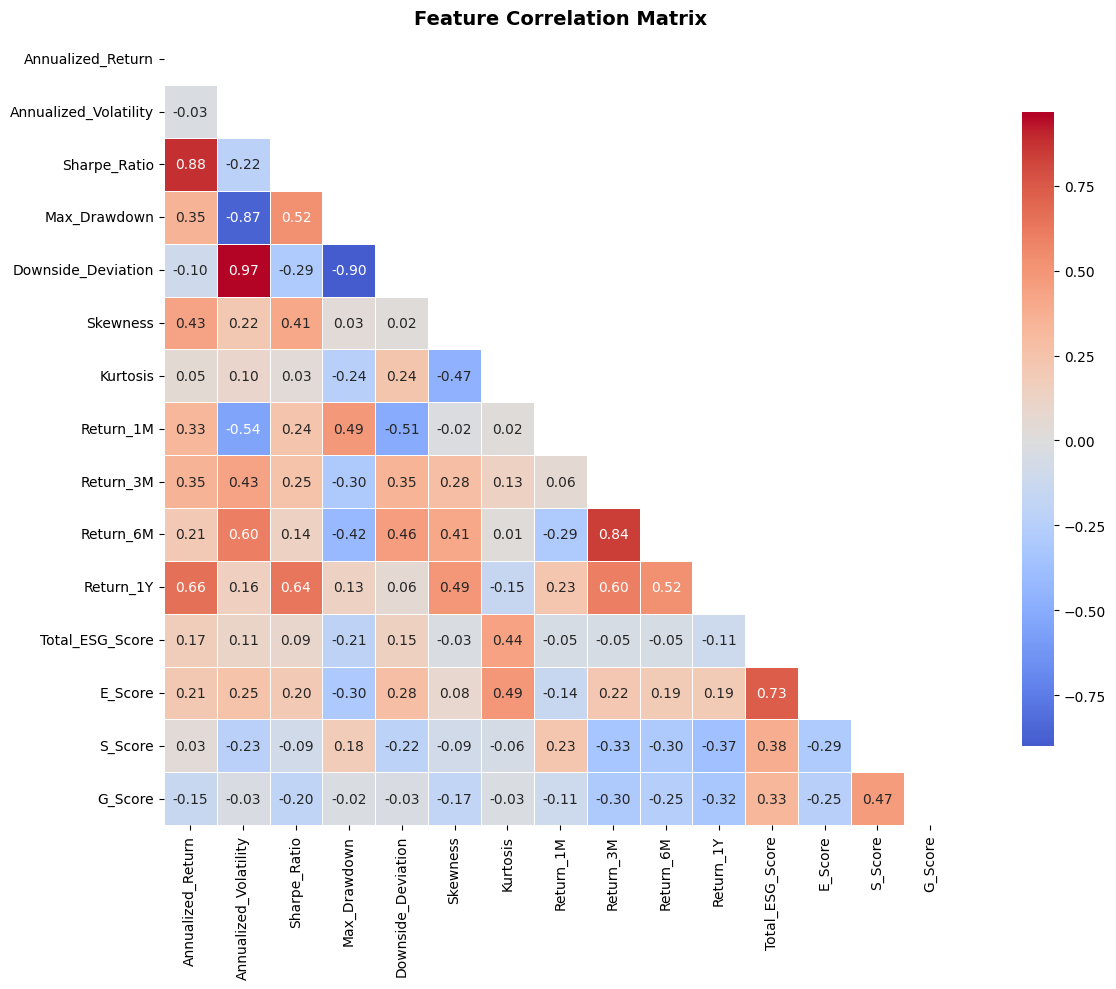

⚠️ Highly correlated feature pairs (|r| > 0.8):
   Annualized_Return <-> Sharpe_Ratio: 0.881
   Annualized_Volatility <-> Max_Drawdown: -0.866
   Annualized_Volatility <-> Downside_Deviation: 0.969
   Max_Drawdown <-> Downside_Deviation: -0.900
   Return_3M <-> Return_6M: 0.840


In [14]:
# Correlation analysis
print("📊 FEATURE CORRELATION ANALYSIS\n")

plt.figure(figsize=(14, 10))
corr_matrix = X_imputed.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify highly correlated features
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print("⚠️ Highly correlated feature pairs (|r| > 0.8):")
    for pair in high_corr_pairs:
        print(f"   {pair[0]} <-> {pair[1]}: {pair[2]:.3f}")
else:
    print("✅ No highly correlated feature pairs found")

---
## 10. Data Validation for Portfolio Optimization

In [15]:
print("✅ DATA VALIDATION FOR ESG PORTFOLIO OPTIMIZATION\n")
print("=" * 60)

validation_results = {}

# 1. Data completeness
print("1️⃣ DATA COMPLETENESS")
completeness_score = 1 - (combined_df.isnull().sum().sum() / (combined_df.shape[0] * combined_df.shape[1]))
validation_results['completeness'] = completeness_score
print(f"   Overall completeness: {completeness_score:.2%}")
print(f"   {'✅ PASS' if completeness_score > 0.9 else '⚠️ WARNING'}")

# 2. Historical data sufficiency
print("\n2️⃣ HISTORICAL DATA SUFFICIENCY")
records_per_ticker = price_df_clean.groupby('Ticker').size()
min_records = records_per_ticker.min()
validation_results['min_history'] = min_records
print(f"   Min trading days per stock: {min_records}")
print(f"   {'✅ PASS' if min_records >= 252 else '⚠️ WARNING'}")

# 3. ESG score distribution
print("\n3️⃣ ESG SCORE DISTRIBUTION")
esg_range = combined_df['Total_ESG_Score'].max() - combined_df['Total_ESG_Score'].min()
esg_std = combined_df['Total_ESG_Score'].std()
validation_results['esg_range'] = esg_range
print(f"   ESG Score Range: {esg_range:.2f}")
print(f"   ESG Score Std Dev: {esg_std:.2f}")
print(f"   {'✅ PASS' if esg_range > 20 else '⚠️ WARNING'}")

# 4. Sector diversity
print("\n4️⃣ SECTOR DIVERSITY")
n_sectors = combined_df['Sector'].nunique()
validation_results['n_sectors'] = n_sectors
print(f"   Number of sectors: {n_sectors}")
print(combined_df['Sector'].value_counts().to_string())
print(f"   {'✅ PASS' if n_sectors >= 5 else '⚠️ WARNING'}")

# 5. Pareto-optimality feasibility
print("\n5️⃣ PARETO FRONTIER FEASIBILITY")
corr_ret_esg = combined_df['Annualized_Return'].corr(combined_df['Total_ESG_Score'])
validation_results['return_esg_corr'] = corr_ret_esg
print(f"   Correlation (Return vs ESG): {corr_ret_esg:.3f}")
print(f"   {'✅ PASS - Trade-off exists' if abs(corr_ret_esg) < 0.7 else '⚠️ High correlation'}")

# 6. RL suitability
print("\n6️⃣ REINFORCEMENT LEARNING SUITABILITY")
n_features = len(feature_columns)
n_samples = len(combined_df)
validation_results['n_features'] = n_features
validation_results['n_samples'] = n_samples
print(f"   Number of features: {n_features}")
print(f"   Number of assets: {n_samples}")
print(f"   {'✅ PASS' if n_samples >= 20 and n_features >= 10 else '⚠️ WARNING'}")

# Summary
print("\n" + "=" * 60)
print("📋 VALIDATION SUMMARY")
print("=" * 60)

checks = [
    ("Data Completeness", validation_results.get('completeness', 0) > 0.9),
    ("Historical Sufficiency", validation_results.get('min_history', 0) >= 252),
    ("ESG Diversity", validation_results.get('esg_range', 0) > 20),
    ("Sector Diversity", validation_results.get('n_sectors', 0) >= 5),
    ("Pareto Feasibility", abs(validation_results.get('return_esg_corr', 1)) < 0.7),
    ("RL Suitability", validation_results.get('n_samples', 0) >= 20)
]

all_pass = True
for check_name, passed in checks:
    status = "✅ PASS" if passed else "❌ FAIL"
    print(f"   {check_name}: {status}")
    all_pass = all_pass and passed

print("\n" + "=" * 60)
if all_pass:
    print("🎉 ALL VALIDATIONS PASSED!")
    print("\nYour data is ready for:")
    print("   • Multi-objective optimization (Pareto Frontier)")
    print("   • Reinforcement Learning for portfolio allocation")
    print("   • ESG penalty/reward function design")
    print("   • Sharpe ratio maximization with ESG constraints")
else:
    print("⚠️ SOME VALIDATIONS NEED ATTENTION")
print("=" * 60)

✅ DATA VALIDATION FOR ESG PORTFOLIO OPTIMIZATION

1️⃣ DATA COMPLETENESS
   Overall completeness: 98.05%
   ✅ PASS

2️⃣ HISTORICAL DATA SUFFICIENCY
   Min trading days per stock: 752
   ✅ PASS

3️⃣ ESG SCORE DISTRIBUTION
   ESG Score Range: 56.00
   ESG Score Std Dev: 12.44
   ✅ PASS

4️⃣ SECTOR DIVERSITY
   Number of sectors: 8
Sector
Technology          5
Healthcare          5
Financials          5
Energy              5
Utilities           5
Consumer Staples    5
Clean Energy        5
Industrials         5
   ✅ PASS

5️⃣ PARETO FRONTIER FEASIBILITY
   Correlation (Return vs ESG): 0.167
   ✅ PASS - Trade-off exists

6️⃣ REINFORCEMENT LEARNING SUITABILITY
   Number of features: 15
   Number of assets: 40
   ✅ PASS

📋 VALIDATION SUMMARY
   Data Completeness: ✅ PASS
   Historical Sufficiency: ✅ PASS
   ESG Diversity: ✅ PASS
   Sector Diversity: ✅ PASS
   Pareto Feasibility: ✅ PASS
   RL Suitability: ✅ PASS

🎉 ALL VALIDATIONS PASSED!

Your data is ready for:
   • Multi-objective optimizati

---
## 11. Visualizations

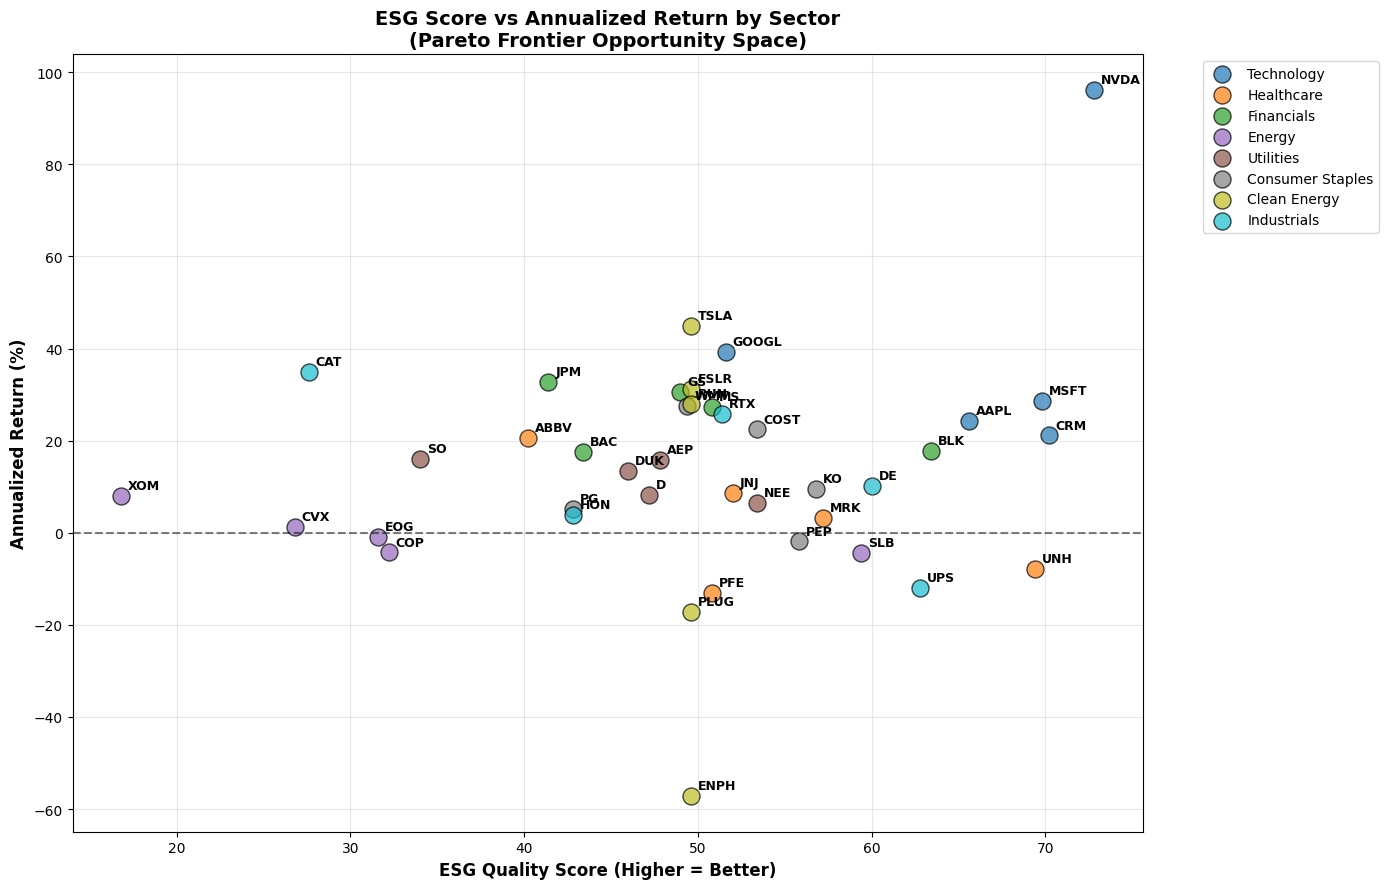

📊 This shows the trade-off space for multi-objective optimization.
   Stocks in the upper-right offer both high returns AND high ESG scores.


In [16]:
# ESG vs Returns - Pareto Frontier Preview
plt.figure(figsize=(14, 9))

sectors = combined_df['Sector'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(sectors)))

for idx, sector in enumerate(sectors):
    sector_data = combined_df[combined_df['Sector'] == sector]
    plt.scatter(sector_data['Total_ESG_Score'],
               sector_data['Annualized_Return'] * 100,
               c=[colors[idx]], label=sector, s=150, alpha=0.7, edgecolor='black', linewidth=1)

    for _, row in sector_data.iterrows():
        plt.annotate(row['Ticker'],
                    (row['Total_ESG_Score'], row['Annualized_Return'] * 100),
                    xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

plt.xlabel('ESG Quality Score (Higher = Better)', fontsize=12, fontweight='bold')
plt.ylabel('Annualized Return (%)', fontsize=12, fontweight='bold')
plt.title('ESG Score vs Annualized Return by Sector\n(Pareto Frontier Opportunity Space)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("📊 This shows the trade-off space for multi-objective optimization.")
print("   Stocks in the upper-right offer both high returns AND high ESG scores.")

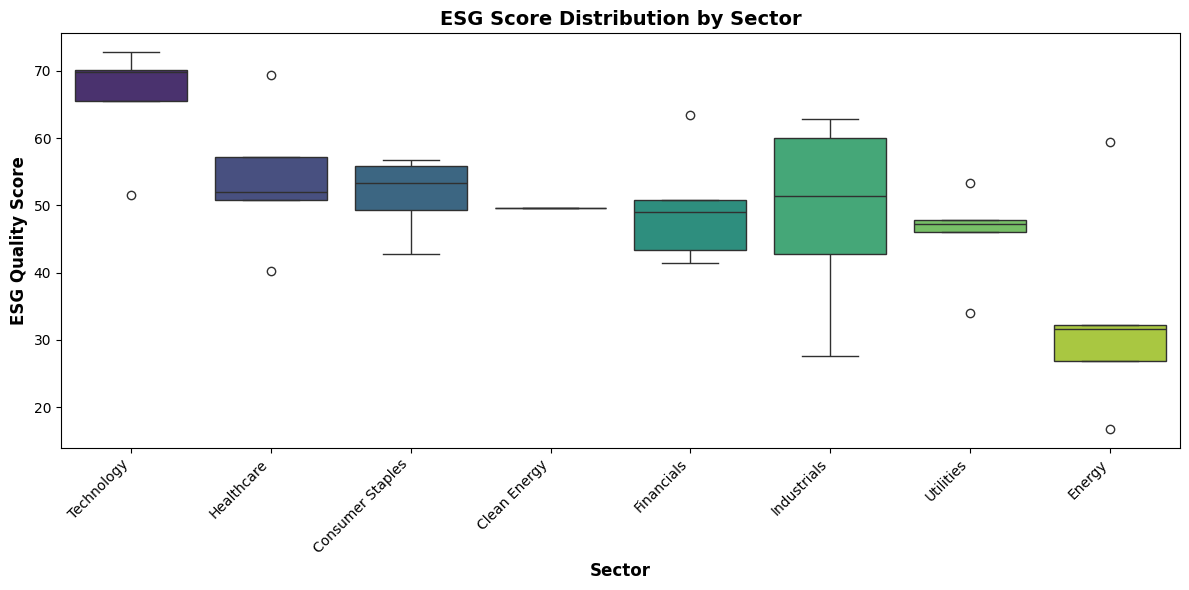

In [17]:
# ESG Score distribution by sector
plt.figure(figsize=(12, 6))

sector_order = combined_df.groupby('Sector')['Total_ESG_Score'].mean().sort_values(ascending=False).index

sns.boxplot(data=combined_df, x='Sector', y='Total_ESG_Score', order=sector_order, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Sector', fontsize=12, fontweight='bold')
plt.ylabel('ESG Quality Score', fontsize=12, fontweight='bold')
plt.title('ESG Score Distribution by Sector', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

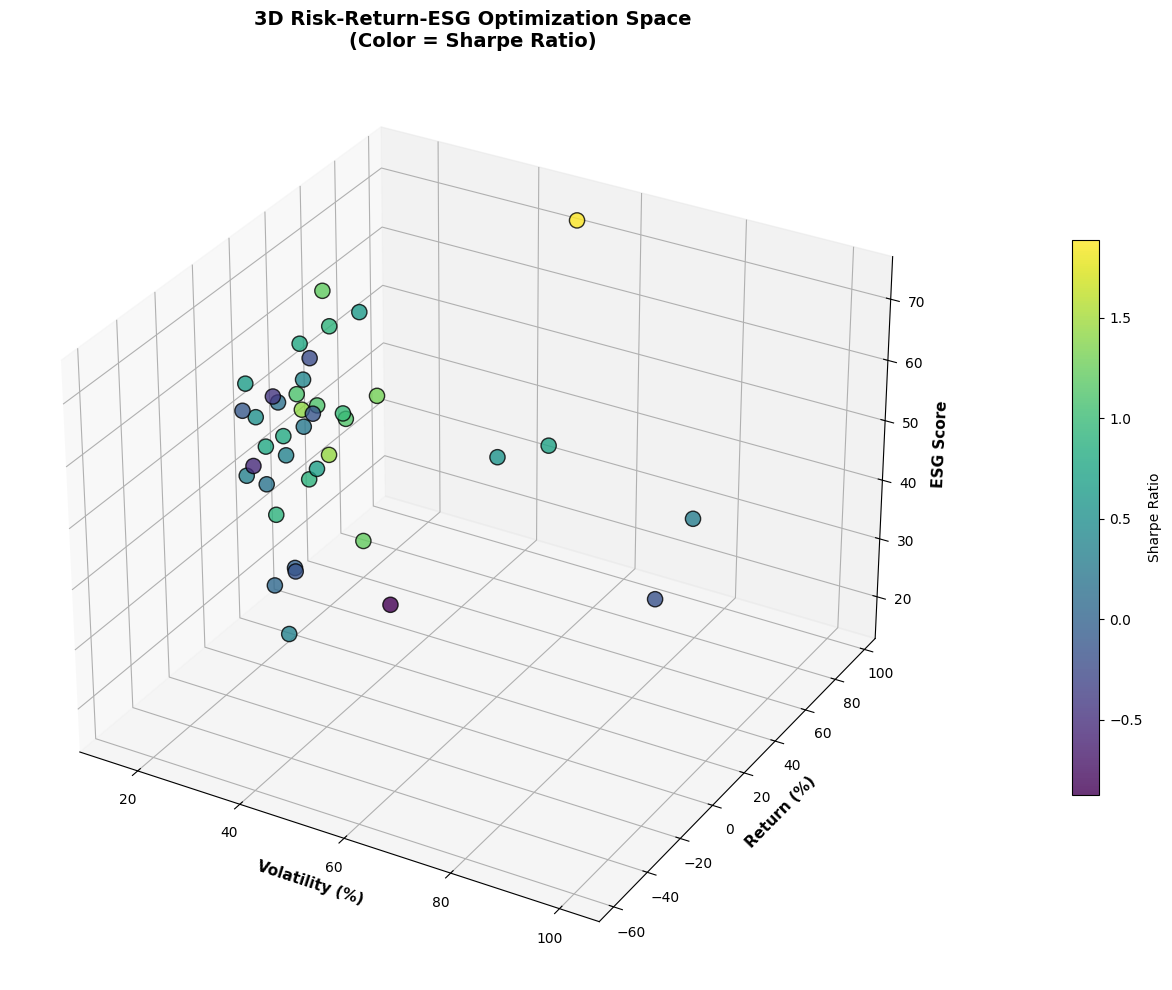

📊 3D visualization of your multi-objective optimization space:
   • X-axis: Risk (volatility)
   • Y-axis: Return
   • Z-axis: ESG Score
   • Color: Sharpe Ratio


In [18]:
# Risk-Return-ESG 3D Plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    combined_df['Annualized_Volatility'] * 100,
    combined_df['Annualized_Return'] * 100,
    combined_df['Total_ESG_Score'],
    c=combined_df['Sharpe_Ratio'],
    cmap='viridis',
    s=120,
    alpha=0.8,
    edgecolor='black'
)

ax.set_xlabel('Volatility (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Return (%)', fontsize=11, fontweight='bold')
ax.set_zlabel('ESG Score', fontsize=11, fontweight='bold')
ax.set_title('3D Risk-Return-ESG Optimization Space\n(Color = Sharpe Ratio)', fontsize=14, fontweight='bold')

plt.colorbar(scatter, ax=ax, label='Sharpe Ratio', shrink=0.6, pad=0.1)
plt.tight_layout()
plt.show()

print("📊 3D visualization of your multi-objective optimization space:")
print("   • X-axis: Risk (volatility)")
print("   • Y-axis: Return")
print("   • Z-axis: ESG Score")
print("   • Color: Sharpe Ratio")

---
## 12. Save Processed Data

In [19]:
print("💾 SAVING PROCESSED DATA\n")
print("=" * 50)

# Save to Google Drive for persistence
output_path = '/content/drive/MyDrive/ESG_Portfolio_Data/'

import os
os.makedirs(output_path, exist_ok=True)

# Save datasets
price_df_clean.to_csv(f'{output_path}stock_prices_cleaned.csv', index=False)
print(f"✅ Stock prices: {output_path}stock_prices_cleaned.csv")

esg_df_clean.to_csv(f'{output_path}esg_scores_cleaned.csv', index=False)
print(f"✅ ESG scores: {output_path}esg_scores_cleaned.csv")

combined_df.to_csv(f'{output_path}combined_features.csv', index=False)
print(f"✅ Combined features: {output_path}combined_features.csv")

X_scaled['Ticker'] = combined_df['Ticker'].values
X_scaled.to_csv(f'{output_path}features_scaled.csv', index=False)
print(f"✅ Scaled features: {output_path}features_scaled.csv")

pd.DataFrame([validation_results]).to_csv(f'{output_path}validation_results.csv', index=False)
print(f"✅ Validation results: {output_path}validation_results.csv")

print(f"\n📁 All files saved to: {output_path}")
print("\nThese files are ready for:")
print("   • Reinforcement Learning model training")
print("   • Pareto Frontier optimization")
print("   • Dashboard visualization (Streamlit/Tableau)")

💾 SAVING PROCESSED DATA

✅ Stock prices: /content/drive/MyDrive/ESG_Portfolio_Data/stock_prices_cleaned.csv
✅ ESG scores: /content/drive/MyDrive/ESG_Portfolio_Data/esg_scores_cleaned.csv
✅ Combined features: /content/drive/MyDrive/ESG_Portfolio_Data/combined_features.csv
✅ Scaled features: /content/drive/MyDrive/ESG_Portfolio_Data/features_scaled.csv
✅ Validation results: /content/drive/MyDrive/ESG_Portfolio_Data/validation_results.csv

📁 All files saved to: /content/drive/MyDrive/ESG_Portfolio_Data/

These files are ready for:
   • Reinforcement Learning model training
   • Pareto Frontier optimization
   • Dashboard visualization (Streamlit/Tableau)


---
## 13. Final Summary

In [20]:
print("="*70)
print("📊 FINAL DATA PIPELINE SUMMARY")
print("="*70)

print(f"\n📈 STOCK PRICE DATA (Velocity + Volume)")
print(f"   Total records: {len(price_df_clean):,}")
print(f"   Date range: {price_df_clean['Date'].min().strftime('%Y-%m-%d')} to {price_df_clean['Date'].max().strftime('%Y-%m-%d')}")
print(f"   Tickers: {price_df_clean['Ticker'].nunique()}")
print(f"   Trading days/stock: ~{len(price_df_clean) // price_df_clean['Ticker'].nunique():,}")

print(f"\n🌱 ESG DATA (Variety)")
print(f"   Companies: {len(esg_df_clean)}")
print(f"   ESG Score Range: {combined_df['Total_ESG_Score'].min():.1f} - {combined_df['Total_ESG_Score'].max():.1f}")
print(f"   Mean ESG Score: {combined_df['Total_ESG_Score'].mean():.1f}")
print(f"   Features: E_Score, S_Score, G_Score, Controversy, Risk Level")

print(f"\n🎯 COMBINED FEATURE SET")
print(f"   Total features: {len(combined_df.columns)}")
print(f"   Financial metrics: {len([c for c in combined_df.columns if any(x in c for x in ['Return', 'Volatility', 'Sharpe', 'Drawdown'])])}")
print(f"   ESG metrics: {len([c for c in combined_df.columns if 'ESG' in c or 'Score' in c])}")
print(f"   Sectors: {combined_df['Sector'].nunique()}")

print(f"\n✅ READY FOR NEXT PHASE:")
print(f"   Week 2: Model Design & Optimization (Sejal)")
print(f"      • Develop RL/Pareto models")
print(f"      • Implement ESG reward/penalty functions")
print(f"      • Constraint optimization")

print("\n" + "="*70)
print("🚀 DATA PIPELINE COMPLETE!")
print("   Week 1 Deliverable: ✅ DONE")
print("="*70)

📊 FINAL DATA PIPELINE SUMMARY

📈 STOCK PRICE DATA (Velocity + Volume)
   Total records: 30,080
   Date range: 2022-11-16 to 2025-11-14
   Tickers: 40
   Trading days/stock: ~752

🌱 ESG DATA (Variety)
   Companies: 40
   ESG Score Range: 16.8 - 72.8
   Mean ESG Score: 49.8
   Features: E_Score, S_Score, G_Score, Controversy, Risk Level

🎯 COMBINED FEATURE SET
   Total features: 32
   Financial metrics: 12
   ESG metrics: 11
   Sectors: 8

✅ READY FOR NEXT PHASE:
   Week 2: Model Design & Optimization (Sejal)
      • Develop RL/Pareto models
      • Implement ESG reward/penalty functions
      • Constraint optimization

🚀 DATA PIPELINE COMPLETE!
   Week 1 Deliverable: ✅ DONE
